# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [129]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
from scipy.io.wavfile import read
from scipy import signal
from IPython.display import Audio
import librosa
from librosa import feature, frames_to_time, autocorrelate, clicks, display, stft
from librosa.feature import zero_crossing_rate, mfcc, spectral_bandwidth, spectral_centroid, spectral_rolloff, chroma_stft
from collections import Counter
from math import ceil, log2, sqrt

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

In [130]:
(fs1,x1) = read('../audio/country.00000.wav')
country = x1/abs(x1).max()
(fs2,x2) = read('../audio/hiphop.00000.wav')
hiphop = x2/abs(x2).max()

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [131]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = 2**ceil(log2(frame_size))

    #else:
        #frame_length = 2**ceil(log2(frame_size))
    # Define hop size is half the frame size
    hop_length = int(frame_length/2)

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = ((len(audio_input)- frame_length) // hop_length) + 1
    if n_mbins %1 != 0:
        n_mbins = round(n_mbins)
    n_mbins = int(n_mbins)

    # Define total number of frequency bins
    n_kbins = int(frame_length//2 + 1)

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins,n_kbins), dtype=complex)

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        frame = (audio_input[m*hop_length:(m*hop_length) + frame_length]) * window
        spectrum = np.fft.rfft(frame)

        stft_matrix[m, :] = spectrum

    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [132]:
countrySTFT = my_stft(country, 128)
countrySTFT

hiphopSTFT = my_stft(hiphop, 128)
hiphopSTFT

array([[-1.79814854e+00+0.00000000e+00j,  1.93483302e+00-2.83589724e-01j,
        -2.66192044e+00+1.22301747e+00j, ...,
         8.55147602e-06+7.70445070e-05j,  4.28457387e-05-6.46434660e-06j,
        -2.92383603e-05+0.00000000e+00j],
       [-1.28480566e+00+0.00000000e+00j,  9.94460756e-01-5.28798975e-01j,
        -1.05475021e+00-6.17849192e-01j, ...,
         7.03274112e-06+6.48121291e-05j, -2.02808296e-04+2.94812144e-05j,
        -6.28068041e-05+0.00000000e+00j],
       [-1.97809058e+00+0.00000000e+00j,  1.18341563e+00+2.72483320e-01j,
        -1.56320763e-01+4.91324606e-01j, ...,
         6.91894133e-06-4.24113401e-05j, -8.94098493e-05-2.04737211e-05j,
         5.55795098e-05+0.00000000e+00j],
       ...,
       [-4.61910820e+00+0.00000000e+00j,  2.41788461e+00-6.88342860e-01j,
         9.24321791e-01+3.20602184e-01j, ...,
         2.52812362e-04-9.23926482e-05j,  1.21635429e-05-2.29916769e-06j,
         1.16447946e-04+0.00000000e+00j],
       [-3.40770281e+00+0.00000000e+00j,  1.

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


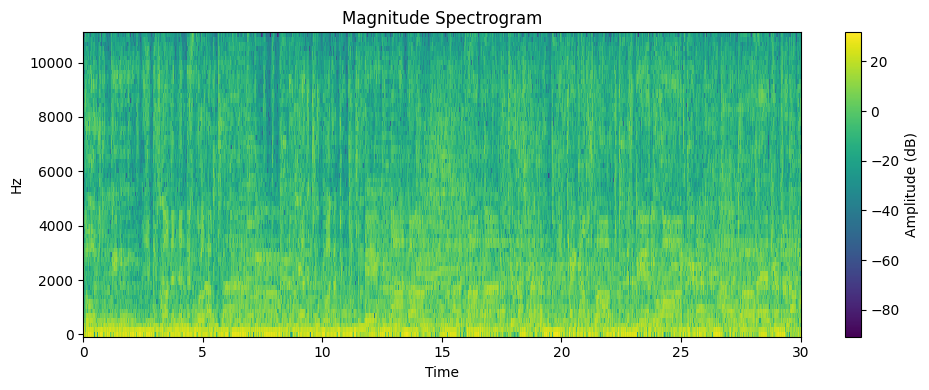

In [ ]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames = stft_matrix.shape[0] # total number of frames
    hop_size =  frame_size // 2  # recall it was 50% of the frame size
    duration = (num_frames * hop_size) // sampling_rate  # find duration
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0, duration, num_frames) 
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0, sampling_rate//2, np.size(stft_matrix, axis=1))

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    plt.figure(figsize=(10,4))
    plt.pcolormesh(time_axis, freq_axis, magnitude_db)

    plt.xlabel("Time")
    plt.ylabel("Hz")
    plt.title("Magnitude Spectrogram")
    plt.colorbar(label="Amplitude (dB)")
    plt.tight_layout()
    plt.show()
    

Plot the spectrogram of the country and hiphop audio files

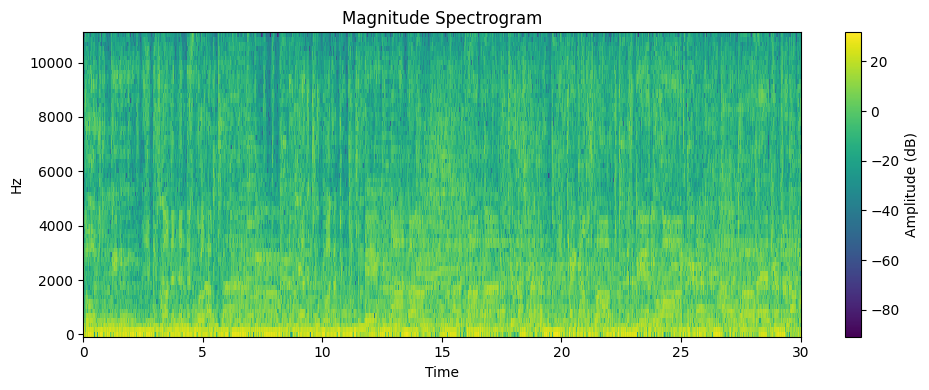

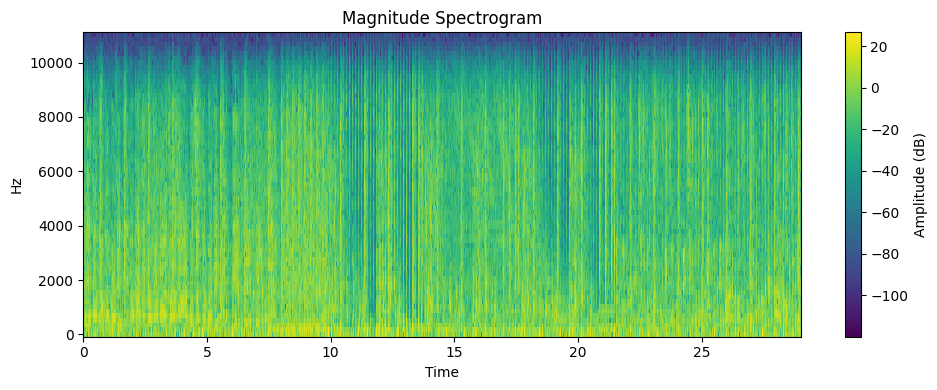

<Figure size 800x400 with 0 Axes>

In [144]:
plot_spectrogram(countrySTFT, 128, fs1)
plot_spectrogram(hiphopSTFT, 128, fs2)
plt.tight_layout()

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

C:\Users\kslap\AppData\Local\Temp\ipykernel_29488\3356918469.py:4: FutureWarning: Pass y=[-0.17154617 -0.02200421  0.01983783 ...  0.07771107  0.03927333
 -0.0213543 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphopRMS = librosa.feature.rms(hiphop.astype(float))
C:\Users\kslap\AppData\Local\Temp\ipykernel_29488\3356918469.py:7: FutureWarning: Pass y=[-0.17343275 -0.25190358 -0.0550361  ...  0.29222393  0.19446088
  0.05479938] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  countryRMS = librosa.feature.rms(country.astype(float))


Text(0, 0.5, 'Energy')

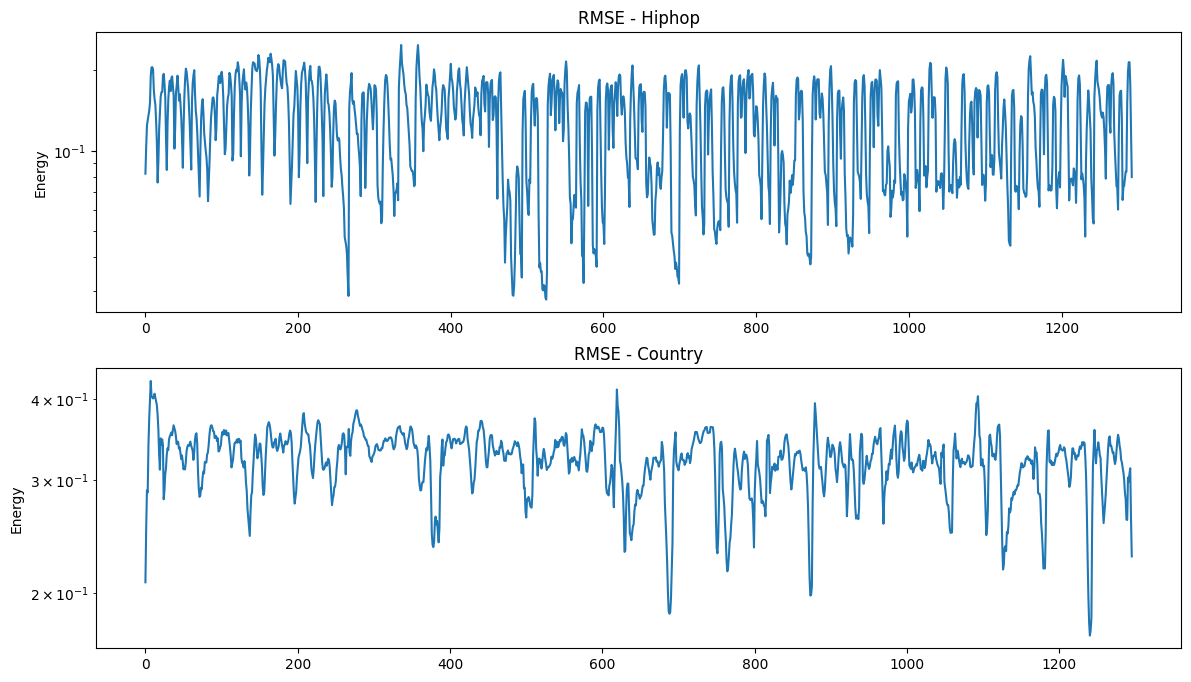

In [134]:
#librosa.feature.rms(y)

# RMSE for hiphop
hiphopRMS = librosa.feature.rms(hiphop.astype(float))

# RMSE for country
countryRMS = librosa.feature.rms(country.astype(float))

# plotting

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphopRMS[0])
plt.title('RMSE - Hiphop')
plt.ylabel('Energy')
plt.subplot(2,1,2)
plt.semilogy(countryRMS[0])
plt.title('RMSE - Country')
plt.ylabel('Energy')


Much like the energy of a signal, the RMSE measures the strength of a signal. The RMSE is more used than just the typical energy calculation, as RMSE can tell us the average energy over the course of a piece, not just a frame.

C:\Users\kslap\AppData\Local\Temp\ipykernel_29488\3687412274.py:3: FutureWarning: Pass y=[-0.17154617 -0.02200421  0.01983783 ...  0.07771107  0.03927333
 -0.0213543 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphopSpecCent = librosa.feature.spectral_centroid(hiphop.astype(float), sr=fs2)
C:\Users\kslap\AppData\Local\Temp\ipykernel_29488\3687412274.py:5: FutureWarning: Pass y=[-0.17343275 -0.25190358 -0.0550361  ...  0.29222393  0.19446088
  0.05479938] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  countrySpecCent = librosa.feature.spectral_centroid(country.astype(float), sr=fs1)


Text(0, 0.5, 'Hz')

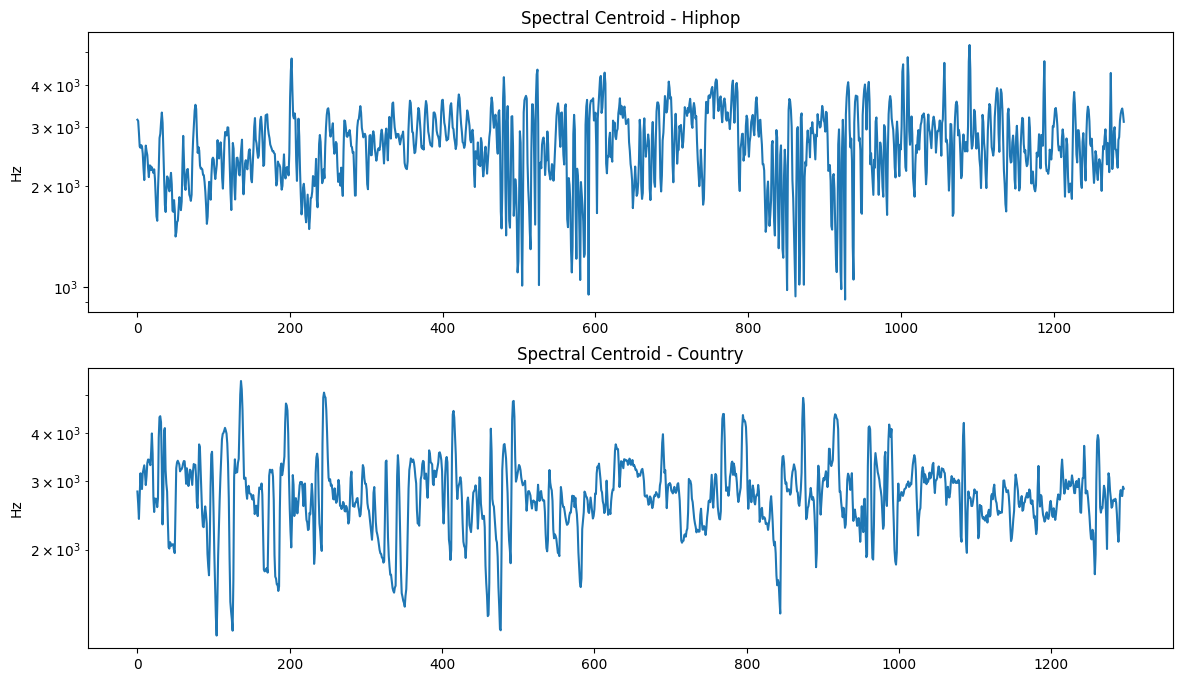

In [135]:
#librosa.feature.spectral_centroid()
# Spectral Centroid for hiphop
hiphopSpecCent = librosa.feature.spectral_centroid(hiphop.astype(float), sr=fs2)
# Spectral Centroid for country
countrySpecCent = librosa.feature.spectral_centroid(country.astype(float), sr=fs1)

# plotting

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphopSpecCent[0])
plt.title('Spectral Centroid - Hiphop')
plt.ylabel('Hz')
plt.subplot(2,1,2)
plt.semilogy(countrySpecCent[0])
plt.title('Spectral Centroid - Country')
plt.ylabel('Hz')

Spectral Centroid is best described as the center of mass of a signal's spectrum. It shows where the majority of the signal's frequency is on the frequency axix. This in turn can show different timbre elements, like parts of a song that might be more bass heavy, or even nasaly. 

Text(0, 0.5, 'Flux')

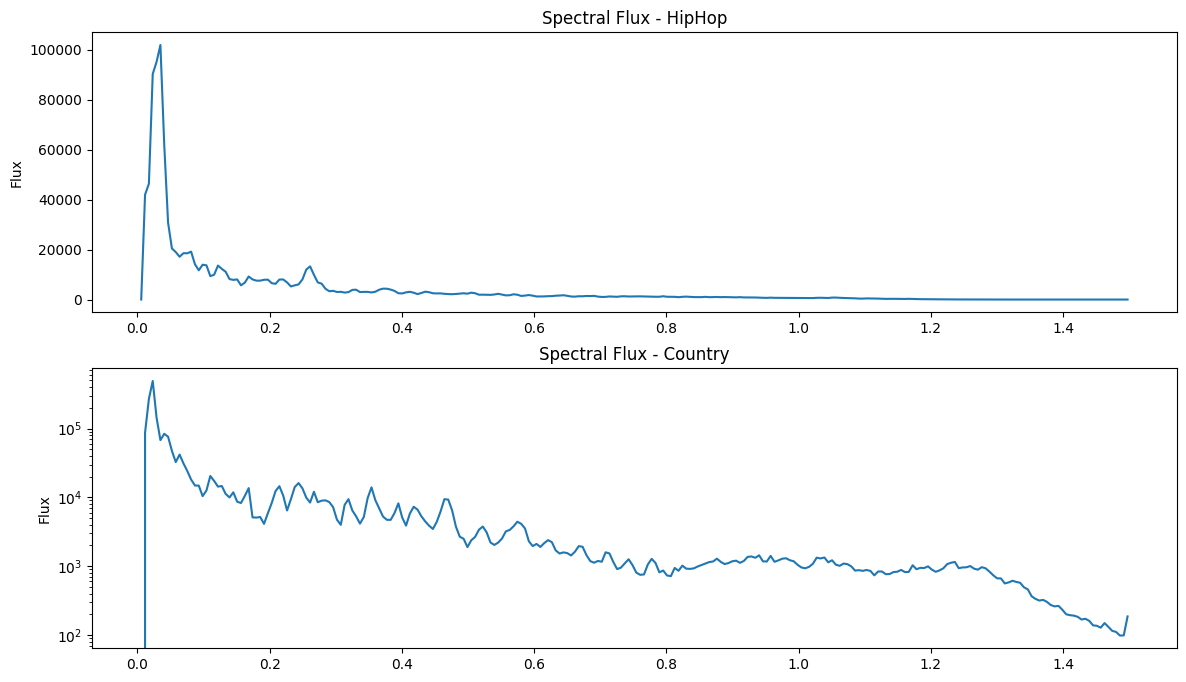

In [136]:
# hiphop
frame_length = 512
hop_length = 128

hh_matrix = my_stft(hiphop, frame_length)

hh_magnitude = np.abs(hh_matrix)

# Frame-to-frame difference
hh_diff = np.diff(hh_magnitude, axis=0)

# Square and sum across frequency bins
hh_flux = np.sum(hh_diff**2, axis=0)

# Pad so output matches frame count
hh_flux = np.concatenate(([0], hh_flux))

frames = range(1,len(hh_flux)+1) #vector of frames as iterable
hh_t = frames_to_time(frames, sr=fs2, hop_length=hop_length)


# country

cc_matrix = my_stft(country, frame_length)

cc_magnitude = np.abs(cc_matrix)

# Frame-to-frame difference
cc_diff = np.diff(cc_magnitude, axis=0)

# Square and sum across frequency bins
cc_flux = np.sum(cc_diff**2, axis=0)

# Pad so output matches frame count
cc_flux = np.concatenate(([0], cc_flux))

frames = range(1,len(cc_flux)+1) #vector of frames as iterable
cc_t = frames_to_time(frames, sr=fs1, hop_length=hop_length)

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.plot(hh_t, hh_flux)
plt.title('Spectral Flux - HipHop')
plt.ylabel('Flux')
plt.subplot(2,1,2)
plt.semilogy(cc_t, cc_flux)
plt.title('Spectral Flux - Country')
plt.ylabel('Flux')




Spectral Flux is a measurement of the spectral shape, or how quickly the power structure changes in a given signal. This is done by comparing the value of each magnitude spectrum bin in the current bin to the one in the previous bin. This more or less used to help determine the timbre of an audio signal. It is also used in onset dection, since the decetion for speech is much higher in speech than audio. 

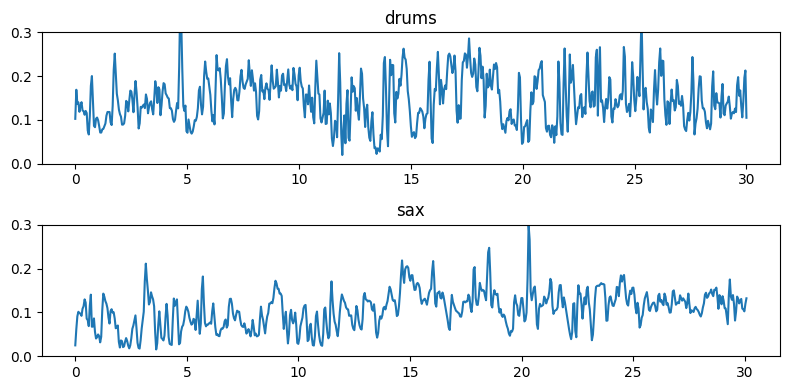

In [137]:
#librosa.feature.zero_crossing_rate()

a = zero_crossing_rate(hiphop.astype(float), hop_length=1024)
b = zero_crossing_rate(country.astype(float), hop_length=1024)

ax1 = np.linspace(0,len(hiphop)/fs2,len(a[0]))
ax2 = np.linspace(0,len(country)/fs1,len(b[0]))

plt.subplot(2,1,1)
plt.plot(ax1, a[0])
plt.ylim(0,0.3)
plt.title('drums')
plt.subplot(2,1,2)
plt.plot(ax2,b[0])
plt.ylim(0,0.3)
plt.title('sax')
plt.tight_layout()

The zero crossing point is a calculation of how many times the signal crosses from a positive to a negative point in a given audio signal. ZCR can also be interpretted as the noisiness of a signal, as it is more prevalent in high, noisy parts, and lower in more "tonal" parts. This means that the ZCR can be used to measure the dominant freq of a specific frame. 

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


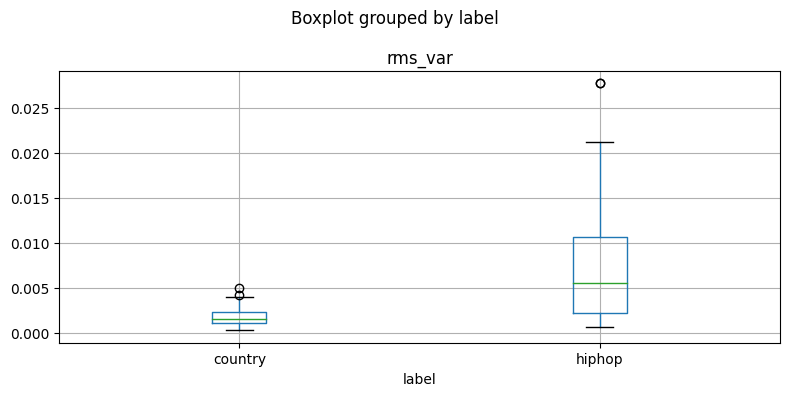

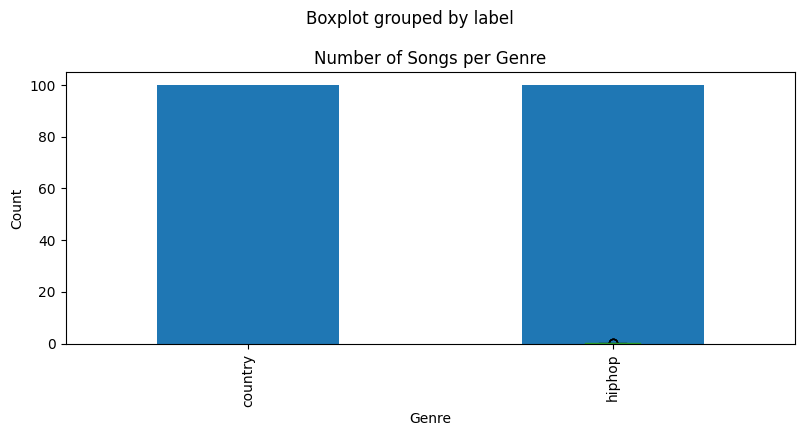

                         spectral_bandwidth_var  spectral_bandwidth_mean  \
spectral_bandwidth_var                 1.000000                 0.069171   
spectral_bandwidth_mean                0.069171                 1.000000   
spectral_centroid_var                  0.584864                 0.579345   
rms_var                                0.445478                 0.298332   
rms_mean                               0.098248                 0.442695   

                         spectral_centroid_var   rms_var  rms_mean  
spectral_bandwidth_var                0.584864  0.445478  0.098248  
spectral_bandwidth_mean               0.579345  0.298332  0.442695  
spectral_centroid_var                 1.000000  0.616916  0.275461  
rms_var                               0.616916  1.000000  0.584927  
rms_mean                              0.275461  0.584927  1.000000  


In [139]:
data = pd.read_csv('../Datasets/features_30_sec.csv')

filteredData = data[data['label'].isin(['country', 'hiphop'])]

filteredData.boxplot(column='rms_var', by='label')
plt.tight_layout()
filteredData.boxplot(column='rms_mean', by='label')
plt.tight_layout()

filteredData['label'].value_counts().plot.bar()
plt.title("Number of Songs per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

dataList = ["label", "spectral_bandwidth_var", "spectral_bandwidth_mean", "spectral_centroid_var", "rms_var", "rms_mean"]
newData = filteredData[dataList]

label = pd.get_dummies(newData['label'],drop_first=True)
features = newData.drop(columns=['label'])
corMtx = features.corr()
print(corMtx)


normalizedFeat = (features - features.mean()) / features.std()

featMtx = pd.concat([label, normalizedFeat], axis=1)



normalized_featMtx=(featMtx-featMtx.mean())/featMtx.std()

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [140]:
categories = label
predictors = normalized_featMtx
pred_train, pred_test, cat_train, cat_test = train_test_split(predictors, categories, test_size = .3, random_state=25)

### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [141]:
model = LogisticRegression(solver='lbfgs') 
model.fit(pred_train, cat_train.values.ravel())
predictions = model.predict(pred_test)

conMtx = confusion_matrix(cat_test, predictions)
conMtxDF = pd.DataFrame(conMtx, index=["Actual Country", "Actual Hiphop"], columns=["Predicted Country", "Predicted Hiphop"])
accuracy = accuracy_score(cat_test, predictions)
precision = precision_score(cat_test, predictions)
recall = recall_score(cat_test, predictions)
f1 = f1_score(cat_test, predictions)
print(conMtxDF)
print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)
print('f1:', f1)



                Predicted Country  Predicted Hiphop
Actual Country                 29                 0
Actual Hiphop                   0                31
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0


The confusion matrix can tell us how many songs were correctly versus incorrectly chosen within the model. The diagonal values represent the correct data types, while the off-diagonal values show incorrect classifications. This confusion matrix shows a suprising 100% correct model, as there is no mis-match between country and hip hop songs based off the feature matrix given. 

Accuracy can tell us the overal performance of the model. It shows the True Positives + True Negatives, all over the data size. It essentially shows the precent of the data that was classififed correctly in a simple 0-100 scale. 

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content